# Baco-Pangeome of Klebsiella 

In [1]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import random

from pathlib import Path
from tqdm import tqdm

/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.


In [2]:
metadata_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/final/metadata_final_curated_slimmed.tsv"
metadata = pd.read_csv(metadata_file, sep="\t", low_memory=False)
print("Metadata shape before indexing:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

Metadata shape before indexing: (88303, 157)
Metadata columns: ['Sample', 'is_kpsc', 'kpsc_final_list', 'is_refseq', 'is_nctc', 'species', 'species_match', 'Clonal group', 'LINcode', 'Phylogroup', 'Sublineage', 'scgST', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'gapA', 'infB', 'mdh', 'pgi', 'phoE', 'rpoB', 'tonB', 'YbST', 'Yersiniabactin', 'ybtS', 'ybtX', 'ybtQ', 'ybtP', 'ybtA', 'irp2', 'irp1', 'ybtU', 'ybtT', 'ybtE', 'fyuA', 'spurious_ybt_hits', 'CbST', 'Colibactin', 'clbA', 'clbB', 'clbC', 'clbD', 'clbE', 'clbF', 'clbG', 'clbH', 'clbI', 'clbL', 'clbM', 'clbN', 'clbO', 'clbP', 'clbQ', 'spurious_clb_hits', 'AbST', 'Aerobactin', 'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'spurious_abst_hits', 'SmST', 'Salmochelin', 'iroB', 'iroC', 'iroD', 'iroN', 'spurious_smst_hits', 'RmST', 'RmpADC', 'rmpA', 'rmpD', 'rmpC', 'spurious_rmst_hits', 'virulence_score', 'spurious_virulence_hits', 'rmpA2', 'AGly_acquired', 'Col_acquired', 'Fcyn_acquired', 'Fl

In [8]:
# Randomly sample 20 genomes from clonal group CG258
cg258_samples = metadata[metadata['Clonal group'] == 'CG258']['Sample'].tolist()
cg258_samples = random.sample(cg258_samples, 30)
# Then collate all the bacfomer embeddings by opening all the bacformer embeddings file and appending them to a single pandas dataframe, indexed by sample
# Initialize an empty pandas dataframe to store embeddings
cg258_sample_embeddings = pd.DataFrame()

embeddings_dir = Path("/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/klebsiella_bacformer_embeddings")
# Loop through each sample in sl258_samples with a progress bar

count_existing_embeddings = 0
for sample in tqdm(cg258_samples, desc="Loading embeddings"):
      # Sample filename is sample_id_bacformer_embeddings.pt (a PyTorch file)
      sample_file = f"{sample}_bacformer_embeddings.pt"
      # Construct the path to the embeddings file
      sample_file_path = embeddings_dir / sample_file
      if sample_file_path.exists():
            # Read the embeddings file (PyTorch format)
            import torch
            sample_embeddings = torch.load(sample_file_path)
            # Pop the first dimension (samples)
            sample_embeddings = sample_embeddings.squeeze(0)
            # Convert to pandas dataframe
            sample_embeddings = pd.DataFrame({'embeddings': [sample_embeddings.numpy()]}, index=[sample])
            # Append the embeddings to the sl258_sample_embeddings dataframe
            cg258_sample_embeddings = pd.concat([cg258_sample_embeddings, sample_embeddings])
            count_existing_embeddings += 1
      else:
            print(f"Embeddings file for {sample} does not exist")

print("Embeddings shape:", cg258_sample_embeddings.shape)
print("Embeddings index (first 5):", cg258_sample_embeddings.index[:5])

Loading embeddings:  30%|███       | 9/30 [00:01<00:02,  9.50it/s]

Embeddings file for SAMN06218023 does not exist


Loading embeddings:  47%|████▋     | 14/30 [00:01<00:01,  9.19it/s]

Embeddings file for GCF_000417265.2_ASM41726v2_genomic does not exist


Loading embeddings:  63%|██████▎   | 19/30 [00:02<00:01,  9.69it/s]

...

Embeddings file for SAMN30861765 does not exist


Loading embeddings:  90%|█████████ | 27/30 [00:03<00:00,  7.00it/s]

Embeddings file for SAMN03280381 does not exist
Embeddings file for SAMN38634938 does not exist


Loading embeddings: 100%|██████████| 30/30 [00:03<00:00,  7.89it/s]

Embeddings shape: (24, 1)
Embeddings index (first 5): Index(['SAMN12342767', 'SAMN12745903', 'SAMEA111435731', 'SAMN16615349',
       'SAMEA112228928'],
      dtype='object')


In [9]:
# Explode embeddings: convert from 91 rows to ~455,000 rows
all_embeddings_list = []
sample_ids_list = []

# Keep as numpy array + separate sample ID list
# embeddings = embeddings_exploded
# sample_ids = sample_ids_list
for sample_id, row in cg258_sample_embeddings.iterrows():
    embedding_matrix = row['embeddings']  # Shape: (~5000, 960)
    all_embeddings_list.append(embedding_matrix)
    # Create sample_id array matching number of genes for this sample
    sample_ids_list.extend([sample_id] * len(embedding_matrix))

# Stack all embeddings into single array
embeddings_exploded = np.vstack(all_embeddings_list)  # Shape: (~455000, 960)

print(f"Exploded embeddings shape: {embeddings_exploded.shape}")
print(f"Sample IDs length: {len(sample_ids_list)}")




Exploded embeddings shape: (130473, 960)
Sample IDs length: 130473


In [10]:
# Create obs DataFrame with sample_id and key metadata columns
obs_df = pd.DataFrame({'sample_id': sample_ids_list})

# Select key metadata columns to include in obs for easy plotting
metadata_cols_to_include = ['Clonal group', 'Sublineage', 'K_locus', 'K_type']

# Set Sample as index for merging
cg258_metadata = metadata.loc[metadata['Clonal group'] == 'CG258',:]
sample_metadata = cg258_metadata.set_index('Sample')

# Join the key metadata columns to obs_df
obs_with_metadata = obs_df.merge(
    sample_metadata[metadata_cols_to_include],
    left_on='sample_id',
    right_index=True,
    how='left'
)

print(f"obs_with_metadata shape: {obs_with_metadata.shape}")
print(f"obs_with_metadata columns: {obs_with_metadata.columns.tolist()}")
print(f"Embeddings shape: {embeddings_exploded.shape}")

# Create AnnData with gene-level embeddings and selected metadata
adata = ad.AnnData(X=embeddings_exploded, obs=obs_with_metadata)

# Store full sample-level metadata in adata.uns for reference if needed
adata.uns['sample_metadata'] = sample_metadata

print(f"\nAnnData X shape: {adata.X.shape}")
print(f"AnnData obs shape: {adata.obs.shape}")
print(f"AnnData obs columns: {adata.obs.columns.tolist()}")
print(f"Full sample metadata stored in adata.uns['sample_metadata']: {adata.uns['sample_metadata'].shape}")

# Check for any missing metadata
print(f"\nMissing metadata check:")
for col in metadata_cols_to_include:
    n_missing = adata.obs[col].isna().sum()
    print(f"  {col}: {n_missing} missing values")

obs_with_metadata shape: (130473, 5)
obs_with_metadata columns: ['sample_id', 'Clonal group', 'Sublineage', 'K_locus', 'K_type']
Embeddings shape: (130473, 960)

AnnData X shape: (130473, 960)
AnnData obs shape: (130473, 5)
AnnData obs columns: ['sample_id', 'Clonal group', 'Sublineage', 'K_locus', 'K_type']
Full sample metadata stored in adata.uns['sample_metadata']: (8847, 156)

Missing metadata check:
  Clonal group: 0 missing values
  Sublineage: 0 missing values
  K_locus: 0 missing values
  K_type: 0 missing values


/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [11]:
# Subsample 20 genomes - that is 20 * ~5000 = ~100,000 genes
# Get unique sample IDs and randomly sample 20
unique_sample_ids = adata.obs['sample_id'].unique().tolist()
# Subsample 20 that are all part of Clonal group CG258
cg258_samples = adata.obs[adata.obs['Clonal group'] == 'CG258']['sample_id'].unique().tolist()
cg258_genome_ids = random.sample(cg258_samples, 20)

print(f"Sampled {len(cg258_genome_ids)} genomes: {cg258_genome_ids[:5]}...")

# Subset the AnnData object to only genes from these 20 samples
adata_cg258_sampled_subset = adata[adata.obs['sample_id'].isin(cg258_genome_ids)].copy()

print(f"Subsetted AnnData shape: {adata_cg258_sampled_subset.shape}")
print(f"Number of unique samples in subset: {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")

# Compute neighbors on the embedding space (X contains the 960-dim embeddings)
sc.pp.neighbors(adata_cg258_sampled_subset, n_neighbors=15, n_pcs=0)  # n_pcs=0 means use X directly

# Compute UMAP
sc.tl.umap(adata_cg258_sampled_subset)

print("UMAP computed successfully!")
print(f"UMAP coordinates shape: {adata_cg258_sampled_subset.obsm['X_umap'].shape}")

Sampled 20 genomes: ['SAMN07212744', 'SAMEA112228928', 'SAMN07212901', 'SAMEA111435731', 'SAMEA6425130']...
Subsetted AnnData shape: (108790, 960)
Number of unique samples in subset: 20
UMAP computed successfully!
UMAP coordinates shape: (108790, 2)


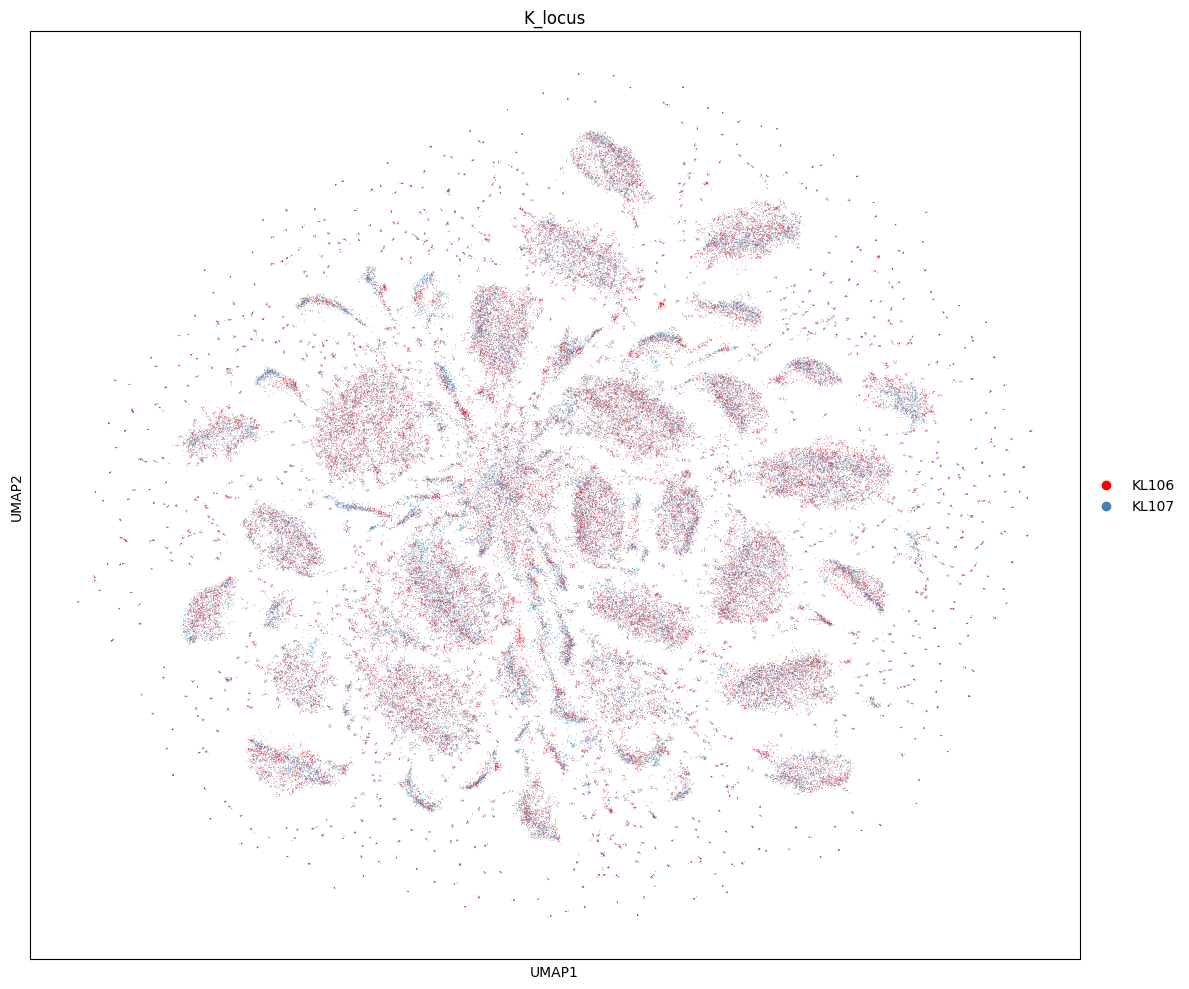


Total points plotted: 108790
Number of samples (colors): 20

K_locus distribution:
K_locus
KL107    65599
KL106    43191
Name: count, dtype: int64


In [13]:
# Plot UMAP colored by K_locus with custom colors
import matplotlib.pyplot as plt

# Define custom color palette for K_locus
k_locus_palette = {
    'KL106': 'red',
    'KL107': 'steelblue',
    'KL25': 'yellow'
}

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot UMAP colored by K_locus with custom palette
sc.pl.umap(adata_cg258_sampled_subset, color='K_locus', palette=k_locus_palette, 
           ax=ax, show=False, legend_loc='right margin')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal points plotted: {adata_cg258_sampled_subset.shape[0]}")
print(f"Number of samples (colors): {adata_cg258_sampled_subset.obs['sample_id'].nunique()}")
print(f"\nK_locus distribution:")
print(adata_cg258_sampled_subset.obs['K_locus'].value_counts())